# EdgeTRM (Official TRM path, notebook-friendly)

This notebook uses the **official TinyRecursiveModels TRM + ACT loss** through a thin adapter, instead of re-implementing recursion in-notebook.

Goal: provide a small, runnable baseline where loss decreases reliably, then you can swap in Sudoku/ARC data.

In [1]:
import torch
# At the top of your notebook, before building the model:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True



In [2]:
!git clone https://github.com/Seqaeon/EdgeTRM.git

Cloning into 'EdgeTRM'...
remote: Enumerating objects: 94, done.
remote: Counting objects: 100% (94/94), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 94 (delta 36), reused 79 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (94/94), 1.86 MiB | 7.86 MiB/s, done.
Resolving deltas: 100% (36/36), done.


In [3]:
!git pull origin main

fatal: not a git repository (or any of the parent directories): .git


In [4]:
import os
# os.chdir("/root/EdgeTRM/TinyRecursiveModels")
os.chdir("/root/EdgeTRM")
print(os.getcwd())


/root/EdgeTRM


In [5]:
from pathlib import Path
import sys

repo_root = Path.cwd()
trm_root = repo_root / "TinyRecursiveModels"
if str(trm_root) not in sys.path:
    sys.path.insert(0, str(trm_root))

print("repo_root:", repo_root)
print("trm_root:", trm_root)

repo_root: /root/EdgeTRM
trm_root: /root/EdgeTRM/TinyRecursiveModels


In [6]:
import torch
print("PyTorch CUDA available:", torch.cuda.is_available())
print("CUDA version (from PyTorch):", torch.version.cuda)
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")


PyTorch CUDA available: True
CUDA version (from PyTorch): 12.9
GPU name: NVIDIA H100 80GB HBM3


In [7]:
# %pip install torch==2.7.0+cu126


In [8]:
# import os
# import subprocess
# req_file = os.path.join(trm_root, "requirements.txt")
# special_req_file = os.path.join(trm_root, "specific_requirements.txt")
# %uv pip install -r {req_file}
# %uv pip install -r {special_req_file}
# # %pip install torch==2.7.0+cu126
%uv pip install {trm_root}


Using Python 3.12.6 environment at: /usr/local
Resolved 63 packages in 1.30s
Building antlr4-python3-runtime==4.9.3
Building antlr4-python3-runtime==4.9.3
Building adam-atan2==0.0.3
Building antlr4-python3-runtime==4.9.3
Building adam-atan2==0.0.3
Building tiny-recursive-models @ file:///root/EdgeTRM/TinyRecursiveModels
Building antlr4-python3-runtime==4.9.3
Building adam-atan2==0.0.3
Building tiny-recursive-models @ file:///root/EdgeTRM/TinyRecursiveModels
⠙ Preparing packages... (0/34)
Building antlr4-python3-runtime==4.9.3
Building adam-atan2==0.0.3
Building tiny-recursive-models @ file:///root/EdgeTRM/TinyRecursiveModels
⠙ Preparing packages... (0/34)
Building antlr4-python3-runtime==4.9.3
Building adam-atan2==0.0.3
Building tiny-recursive-models @ file:///root/EdgeTRM/TinyRecursiveModels
⠙ Preparing packages... (0/34)
omegaconf  ------------------------------ 14.76 KiB/77.64 KiB
Building antlr4-python3-runtime==4.9.3
Building adam-atan2==0.0.3
Building tiny-recursive-models @ file

In [9]:
import torch
from edge_trm_wrapper import EdgeTRMAdapter, EdgeTRMBatch

torch.manual_seed(7)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


In [10]:
BATCH = 128
# ── Global experiment flags ─────────────────────────────────────────────────
SMOKE_TEST       = False          # True → quick run for CI / sanity; False → full eval
DEVICE           = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED             = 42
EPOCHS = 200 if SMOKE_TEST else 5000
torch.manual_seed(SEED)
np.random.seed(SEED)

NameError: name 'np' is not defined

## 1) Tiny config (fast sanity training)

This is intentionally tiny and uses `halt_max_steps=1` so each iteration is straightforward for debugging.

In [11]:
cfg = {
    "batch_size": 32,
    "seq_len": 12,
    "puzzle_emb_ndim": 0,
    "num_puzzle_identifiers": 1,
    "vocab_size": 16,
    "H_cycles": 1,
    "L_cycles": 1,
    "H_layers": 0,
    "L_layers": 1,
    "hidden_size": 64,
    "expansion": 2.0,
    "num_heads": 4,
    "pos_encodings": "rope",
    "halt_max_steps": 1,
    "halt_exploration_prob": 0.0,
    "forward_dtype": "float32",
    "mlp_t": False,
    "puzzle_emb_len": 0,
    "no_ACT_continue": True,
}

model = EdgeTRMAdapter(cfg, loss_type="stablemax_cross_entropy").to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
print("params:", sum(p.numel() for p in model.parameters()))

params: 67714


## 2) Synthetic task

Identity token reconstruction (`labels = inputs`).

If the training path is wired correctly, the loss should trend down quickly.

In [12]:
def make_batch(batch_size=32, seq_len=12, vocab_size=16, device=device):
    x = torch.randint(0, vocab_size, (batch_size, seq_len), device=device)
    y = x.clone()
    puzzle_ids = torch.zeros((batch_size,), dtype=torch.int32, device=device)
    return EdgeTRMBatch(inputs=x, labels=y, puzzle_identifiers=puzzle_ids)

In [13]:
model.train()
losses = []
lm_losses = []
accs = []

# fixed batch so you can verify optimization wiring by overfitting
batch = make_batch(cfg["batch_size"], cfg["seq_len"], cfg["vocab_size"])
carry = model.initial_carry(batch)
# Move carry tensors to selected device
carry.inner_carry.z_H = carry.inner_carry.z_H.to(device)
carry.inner_carry.z_L = carry.inner_carry.z_L.to(device)
carry.steps = carry.steps.to(device)
carry.halted = carry.halted.to(device)
carry.current_data = {k: v.to(device) for k, v in carry.current_data.items()}

for step in range(300):
    carry, loss, metrics, _, done = model.train_step(batch=batch, carry=carry)

    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    optimizer.step()

    losses.append(float(loss.detach().cpu()))
    lm_losses.append(float((metrics["lm_loss"] / metrics["count"]).detach().cpu()))
    accs.append(float((metrics["accuracy"] / metrics["count"]).detach().cpu()))

    if step % 50 == 0:
        print(
            f"step={step:03d} total={losses[-1]:.4f} lm={lm_losses[-1]:.4f} tok_acc={accs[-1]:.4f}"
        )

print("start_lm_loss:", lm_losses[0], "end_lm_loss:", lm_losses[-1])
print("start_acc:", accs[0], "end_acc:", accs[-1])

step=000 total=95.4219 lm=2.9786 tok_acc=0.0156
step=050 total=110.2848 lm=1.0602 tok_acc=1.0000
step=100 total=86.3422 lm=0.8416 tok_acc=1.0000
step=150 total=65.0449 lm=0.7760 tok_acc=1.0000
step=200 total=46.6439 lm=0.7083 tok_acc=1.0000
step=250 total=33.0289 lm=0.6421 tok_acc=1.0000
start_lm_loss: 2.978577982430057 end_lm_loss: 0.5739227251447174
start_acc: 0.015625 end_acc: 1.0


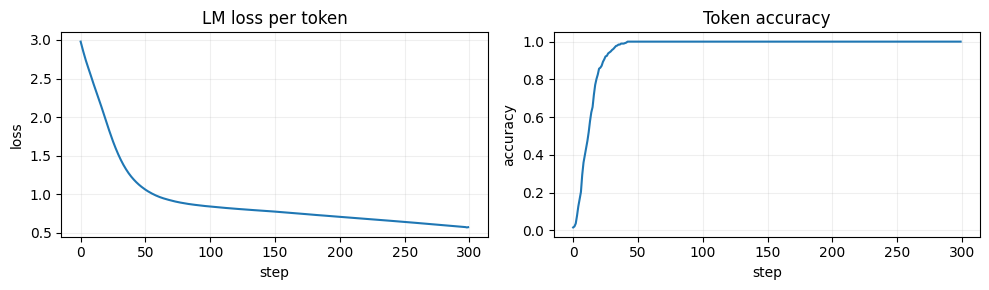

In [14]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(lm_losses)
ax[0].set_title("LM loss per token")
ax[0].set_xlabel("step")
ax[0].set_ylabel("loss")
ax[0].grid(alpha=0.2)

ax[1].plot(accs)
ax[1].set_title("Token accuracy")
ax[1].set_xlabel("step")
ax[1].set_ylabel("accuracy")
ax[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [22]:

import subprocess
from pathlib import Path
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

# Build a small Sudoku dataset using the official TinyRecursiveModels builder
# (downloads from Hugging Face dataset used by the repo).
data_dir = Path('TinyRecursiveModels/data/sudoku-notebook')
if not data_dir.exists():
    cmd = [
        'python', 'dataset/build_sudoku_dataset.py',
        '--output-dir', 'data/sudoku-notebook',
        '--subsample-size', '2048',
        '--num-aug', '0',
    ]
    subprocess.run(cmd, cwd='TinyRecursiveModels', check=True)

print('dataset dir:', data_dir.resolve())

100%|█████████████████████████████████████████████████████████████| 422786/422786 [00:00<00:00, 2188010.76it/s]


dataset dir: /root/EdgeTRM/TinyRecursiveModels/data/sudoku-notebook


In [23]:

# Load official-format arrays produced by the dataset builder
train_inputs = np.load('TinyRecursiveModels/data/sudoku-notebook/train/all__inputs.npy')
train_labels = np.load('TinyRecursiveModels/data/sudoku-notebook/train/all__labels.npy')
test_inputs  = np.load('TinyRecursiveModels/data/sudoku-notebook/test/all__inputs.npy')
test_labels  = np.load('TinyRecursiveModels/data/sudoku-notebook/test/all__labels.npy')

# Split train into train/val
n_train = int(0.85 * len(train_inputs))
X_train, Y_train = train_inputs[:n_train], train_labels[:n_train]
X_val, Y_val = train_inputs[n_train:], train_labels[n_train:]
X_test, Y_test = test_inputs, test_labels

def make_loader(X_np, Y_np, batch_size=64, shuffle=True):
    ds = TensorDataset(torch.from_numpy(X_np), torch.from_numpy(Y_np))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=True)

train_loader = make_loader(X_train, Y_train, batch_size=64, shuffle=True)
val_loader = make_loader(X_val, Y_val, batch_size=64, shuffle=False)
test_loader = make_loader(X_test, Y_test, batch_size=64, shuffle=False)

print('shapes:', X_train.shape, X_val.shape, X_test.shape)
     

shapes: (1740, 81) (308, 81) (422786, 81)


In [15]:
# import numpy as np
# from torch.utils.data import TensorDataset, DataLoader

# try:
#     from sudoku import Sudoku
# except Exception as e:
#     raise RuntimeError("Install py-sudoku first: pip install sudoku") from e


# def generate_sudoku_pair(difficulty: float = 0.6, seed: int | None = None):
#     rng = np.random.default_rng(seed)
#     puzzle = Sudoku(3, seed=int(rng.integers(0, 1_000_000))).difficulty(difficulty)
#     solution = puzzle.solve()
#     if solution.board is None:
#         return None

#     def board_to_flat(board):
#         return np.array([0 if v is None else v for row in board for v in row], dtype=np.int64)

#     return board_to_flat(puzzle.board), board_to_flat(solution.board)


# def build_sudoku_arrays(n_puzzles: int = 2048, difficulty: float = 0.6, seed: int = 123):
#     rng = np.random.default_rng(seed)
#     puzzles, solutions = [], []
#     while len(puzzles) < n_puzzles:
#         pair = generate_sudoku_pair(difficulty=difficulty, seed=int(rng.integers(0, 1_000_000)))
#         if pair is None:
#             continue
#         p, s = pair
#         puzzles.append(p)
#         solutions.append(s)
#     X = np.stack(puzzles)
#     Y = np.stack(solutions)
#     return X, Y

RuntimeError: Install py-sudoku first: pip install sudoku

In [16]:
# # Build train/val/test arrays
# X, Y = build_sudoku_arrays(n_puzzles=3072, difficulty=0.6, seed=7)

# n_train, n_val = 2304, 384
# X_train, Y_train = X[:n_train], Y[:n_train]
# X_val, Y_val = X[n_train:n_train+n_val], Y[n_train:n_train+n_val]
# X_test, Y_test = X[n_train+n_val:], Y[n_train+n_val:]

# def make_loader(X_np, Y_np, batch_size=64, shuffle=True):
#     ds = TensorDataset(torch.from_numpy(X_np), torch.from_numpy(Y_np))
#     return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=True)

# train_loader = make_loader(X_train, Y_train, batch_size=64, shuffle=True)
# val_loader = make_loader(X_val, Y_val, batch_size=64, shuffle=False)
# test_loader = make_loader(X_test, Y_test, batch_size=64, shuffle=False)

# print(len(train_loader), len(val_loader), len(test_loader))

NameError: name 'build_sudoku_arrays' is not defined

In [24]:

def edge_batch_from_xy(x: torch.Tensor, y: torch.Tensor, device: torch.device):
    x = x.to(device=device, dtype=torch.int32)
    y = y.to(device=device, dtype=torch.int32)
    puzzle_ids = torch.zeros((x.shape[0],), dtype=torch.int32, device=device)
    return EdgeTRMBatch(inputs=x, labels=y, puzzle_identifiers=puzzle_ids)


def make_sudoku_cfg(batch_size: int = 64):
    return {
        "batch_size": batch_size,
        "seq_len": 81,
        "puzzle_emb_ndim": 0,
        "num_puzzle_identifiers": 1,
        "vocab_size": 10,   # digits 0..9
        "H_cycles": 3,
        "L_cycles": 6,
        "H_layers": 0,
        "L_layers": 2,
        "hidden_size": 256,
        "expansion": 4.0,
        "num_heads": 8,
        "pos_encodings": "rope",
        "halt_max_steps": 8,
        "halt_exploration_prob": 0.1,
        "forward_dtype": "float32",
        "mlp_t": False,
        "puzzle_emb_len": 0,
        "no_ACT_continue": True,
    }

In [25]:
sudoku_cfg = make_sudoku_cfg(batch_size=BATCH)
sudoku_model = EdgeTRMAdapter(sudoku_cfg, loss_type="stablemax_cross_entropy").to(device)
sudoku_opt = torch.optim.AdamW(sudoku_model.parameters(), lr=1e-4, weight_decay=1.0, betas=(0.9, 0.95))

# Initialize carry once and keep recurrent updates across batches
init_x, init_y = next(iter(train_loader))
init_batch = edge_batch_from_xy(init_x, init_y, device)
carry = sudoku_model.initial_carry(init_batch)
carry.inner_carry.z_H = carry.inner_carry.z_H.to(device)
carry.inner_carry.z_L = carry.inner_carry.z_L.to(device)
carry.steps = carry.steps.to(device)
carry.halted = carry.halted.to(device)
carry.current_data = {k: v.to(device) for k, v in carry.current_data.items()}

In [19]:
def run_epoch(model, loader, optimizer=None, carry=None):
    train_mode = optimizer is not None
    model.train(train_mode)

    lm_sum = acc_sum = count_sum = 0.0

    for x, y in loader:
        batch = edge_batch_from_xy(x, y, device)

        if carry is None:
            carry = model.initial_carry(batch)
            carry.inner_carry.z_H = carry.inner_carry.z_H.to(device)
            carry.inner_carry.z_L = carry.inner_carry.z_L.to(device)
            carry.steps = carry.steps.to(device)
            carry.halted = carry.halted.to(device)
            carry.current_data = {k: v.to(device) for k, v in carry.current_data.items()}

        with torch.set_grad_enabled(train_mode):
            carry, loss, metrics, _, _ = model.train_step(batch=batch, carry=carry)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

        lm_sum += float(metrics["lm_loss"].detach().cpu())
        acc_sum += float(metrics["accuracy"].detach().cpu())
        count_sum += float(metrics["count"].detach().cpu())

    return {"lm": lm_sum / max(count_sum, 1.0), "tok_acc": acc_sum / max(count_sum, 1.0)}, carry

In [26]:

# Quick token-range sanity check before training
xb, yb = next(iter(train_loader))
print('x range:', xb.min().item(), xb.max().item(), 'y range:', yb.min().item(), yb.max().item())

# EPOCHS = 10
for epoch in range(EPOCHS):
    tr, carry = run_epoch(sudoku_model, train_loader, optimizer=sudoku_opt, carry=carry)
    va, carry = run_epoch(sudoku_model, val_loader, optimizer=None, carry=carry)
    print(f"epoch={epoch:02d} train_lm={tr['lm']:.4f} train_tok_acc={tr['tok_acc']:.4f} val_lm={va['lm']:.4f} val_tok_acc={va['tok_acc']:.4f}")

/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [2952,0,0], thread: [32,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather kernel index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [2952,0,0], thread: [33,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather kernel index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [2952,0,0], thread: [34,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather kernel index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [2952,0,0], thread: [35,0,0] Assertion `ind >=0 && ind < ind_dim_size && "vectorized gather kernel index out of bounds"` failed.
/pytorch/aten/src/ATen/native/cuda/IndexKernelUtils.cu:16: vectorized_gather_kernel: block: [2952,0,0], thread: [36,

RuntimeError: CUDA error: CUBLAS_STATUS_EXECUTION_FAILED when calling `cublasSgemm( handle, opa, opb, m, n, k, &alpha, a, lda, b, ldb, &beta, c, ldc)`